# Level 3b Advanced YOLOV26x

**Task** : Binary classification - `stage III` vs `stage IV`
**Model** : yolo26x-cls.pt
**Platform** : Kaggle (GPU T4 x2)

> This is level 3b of the cascade pipeline. The model only ever sees confirmed advanced-stage pressure sores. Its sole job is to distinguish full-thickness skin loss with visible fat (Stage III) from full-thickness tissue loss exposing muscle or bone (Stage IV)


---

### Clinical Context

| Stage | Definition | Key visual feature |
|---|---|---|
| **III** | Full-thickness skin loss, subcutaneous fat visible | Deep crater, no exposed tendon/bone |
| **IV** | Full-thickness tissue loss, muscle/tendon/bone exposed | Exposed deep structures, often with eschar or slough |

Stage III and IV are the hardest pair in the entire cascade — both present as deep open wounds. The distinction depends on whether underlying structures (muscle, tendon, bone) are visible, which is often subtle in 2D photographs and may require depth cues not available to a classifier. **Lower accuracy here compared to other levels is expected and should be documented, not hidden.**

---

## Notebook Structure


1. Environment & imports  
2. Dataset preparation & split  
3. Class distribution analysis  
4. Training  
5. Training curve analysis  
6. Evaluation — confusion matrix (raw + normalised)  
7. Evaluation — full classification report  
8. Evaluation — ROC curve & AUC  
9. Evaluation — threshold sensitivity analysis   
10. Model export & summary 


## 1. Environment & Imports

In [1]:
!pip install -q ultralytics 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.6 MB/s eta 0:00:00a 0:00:01


In [2]:
import os, shutil, random 
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, roc_auc_score
from ultralytics import YOLO

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FIGSIZE = (10,7)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2. Dataset Preparation & Split

Source layout expected —  only advanced-stage PS images:
```
source_dir/
  stage I/     ← full-thickness skin loss, fat visible, no exposed deep structures  
  stage II/    ← full-thickness tissue loss, muscle/tendon/bone exposed
```

In [3]:
YOLO_BACKBONE = "yolo26x-cls.pt"

SOURCE_DIR = "/kaggle/input/datasets/cezarytubacki/psd-advanced-stages/PSD - advanced"
DEST_DIR = "/kaggle/working/cascade_l3_advanced_yolo"

TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10

def split_dataset_for_yolo(
    source_dir: str, 
    dest_dir: str, 
    train_ratio: float = TRAIN_RATIO,
    val_ratio: float = VAL_RATIO,
    test_ratio: float = TEST_RATIO,
) -> dict:
    """
    Split an image classification dataset into YOLO train/val/test format.
    Returns a dict with per-class counts for distribution analysis.
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1.0"
    counts = {split : {} for split in ["train", "val", "test"]}

    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(dest_dir, split), exist_ok=True)

    for class_folder in sorted(os.listdir(source_dir)):
        class_path = os.path.join(source_dir, class_folder)
        if not os.path.isdir(class_path):
            continue

        for split in ["train", "val", "test"]:
            os.makedirs(os.path.join(dest_dir, split, class_folder), exist_ok=True)

        images = [
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
            and f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
        ]
        random.shuffle(images)

        train_end = int(len(images) * train_ratio)
        val_end = train_end + int(len(images) * val_ratio)

        split_map = {
            "train" : images[:train_end],
            "val" : images[train_end:val_end],
            "test" : images[val_end:],
        }

        for split, split_images in split_map.items():
            for img in split_images:
                shutil.copy(
                    os.path.join(class_path, img),
                    os.path.join(dest_dir, split, class_folder, img)
                )
            counts[split][class_folder] = len(split_images)
    return counts 

split_counts = split_dataset_for_yolo(SOURCE_DIR, DEST_DIR)

print("Split complete.")
for split, classes in split_counts.items():
    total = sum(classes.values())
    print(f" {split:6s} : {total:4d} images | {classes}")

Split complete.
 train  :  434 images | {'stage III': 217, 'stage IV': 217}
 val    :  124 images | {'stage III': 62, 'stage IV': 62}
 test   :   62 images | {'stage III': 31, 'stage IV': 31}


## 3. Class Distribution Analysis

Visualise class balance across splits before training. Imbalanced datasets directly affect threshold choice and metric interpretation.

Image counts per split and class:


,stage III,stage IV,total
train,217,217,434
val,62,62,124
test,31,31,62


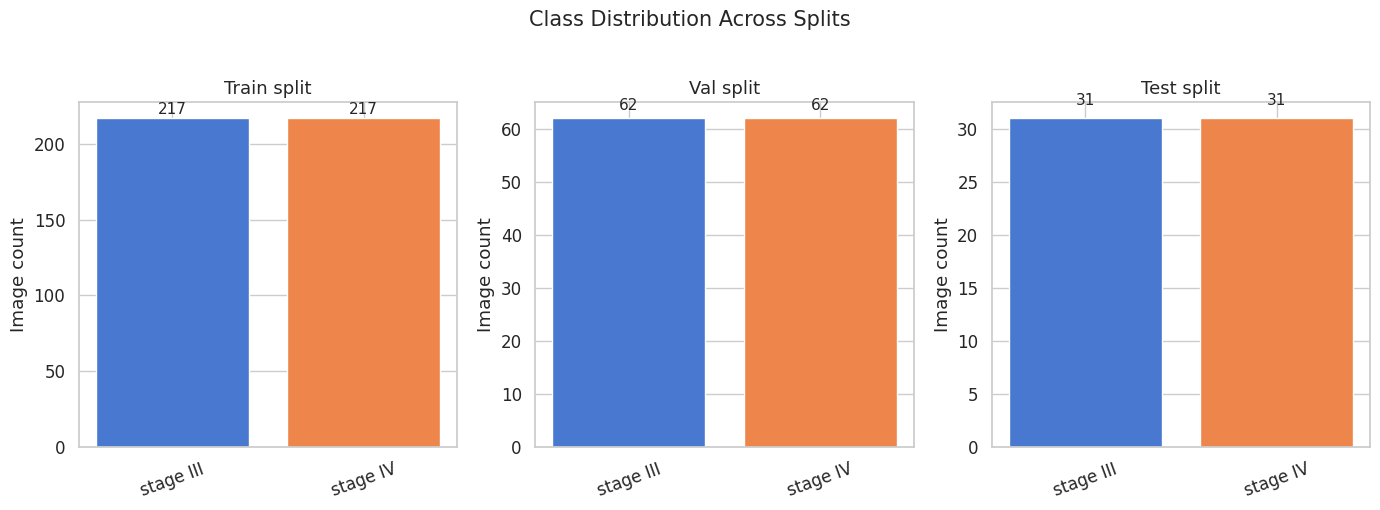

  train  imbalance ratio (majority/minority): 1.00 
  val    imbalance ratio (majority/minority): 1.00 
  test   imbalance ratio (majority/minority): 1.00 


In [4]:
splits = list(split_counts.keys())
classes = list(next(iter(split_counts.values())).keys())

df_counts = pd.DataFrame(split_counts).T   # rows=splits, cols=classes
df_counts["total"] = df_counts.sum(axis=1)

print("Image counts per split and class:")
display(df_counts)

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
for ax, split in zip(axes, splits):
    vals = [split_counts[split].get(c, 0) for c in classes]
    bars = ax.bar(classes, vals, color=sns.color_palette("muted", len(classes)))
    ax.set_title(f"{split.capitalize()} split", fontsize=13)
    ax.set_ylabel("Image count")
    ax.tick_params(axis="x", rotation=20)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1, str(v),
                ha="center", va="bottom", fontsize=11)

plt.suptitle("Class Distribution Across Splits", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Imbalance ratio
for split in splits:
    vals = list(split_counts[split].values())
    ratio = max(vals) / min(vals) if min(vals) > 0 else float("inf")
    if ratio > 3.0:
        flag = "  ⚠️  severe imbalance — strongly consider augmentation or class weights"
    elif ratio > 2.0:
        flag = "  ⚠️  moderate imbalance — consider augmentation"
    else:
        flag = ""
    print(f"  {split:6s} imbalance ratio (majority/minority): {ratio:.2f} {flag}")

## 4. Training


In [5]:
model = YOLO(YOLO_BACKBONE)

results = model.train(
    data=DEST_DIR,
    epochs = 100,
    imgsz = 224,
    batch = 32,
    patience = 10,
    verbose = True,
    project = "/kaggle/working/runs",
    name = "cascade_l3_advanced"
)

BEST_WEIGHTS = "/kaggle/working/runs/cascade_l3_advanced/weights/best.pt"
print(f"\nBest weights saved to: {BEST_WEIGHTS}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cascade_l3_advanced_yolo, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cascade_l3_advanced, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

## 5. Training Curve Analysis

Check for overfitting: train and val loss should coverage. For a small dataset this gap will appear earlier that at Levels 1/2 - that is expected. What matters is whether the val accuracy plateau is clinically acceptable.

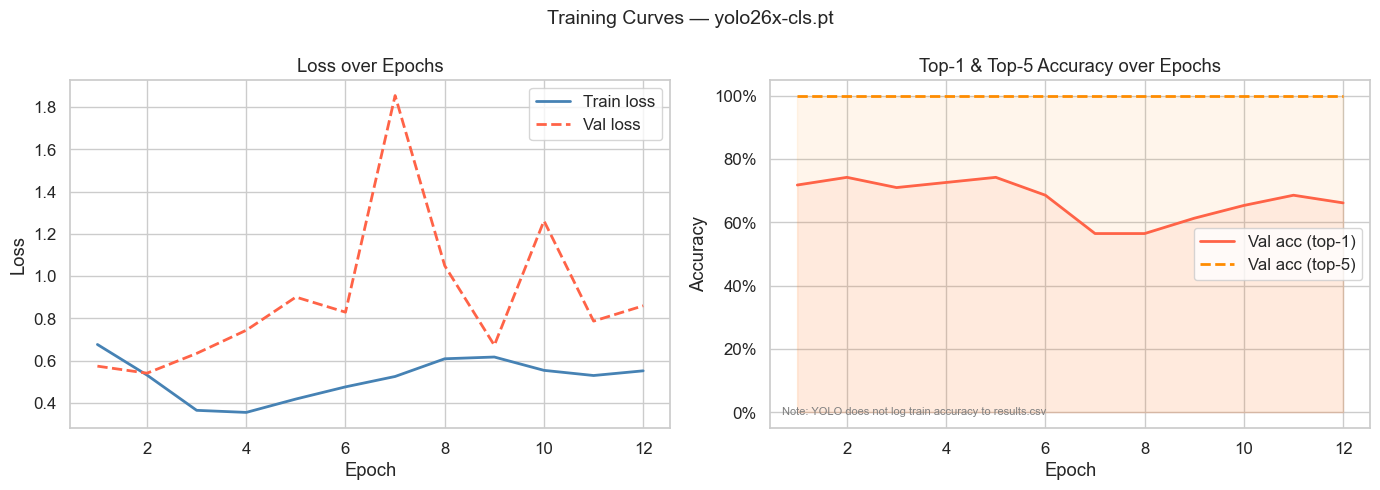

Best val top-1 accuracy at epoch 2  (0.7419)
Best val top-5 accuracy at epoch 1  (1.0000)


In [6]:
results_csv = Path("/kaggle/working/runs/cascade_l3_advanced/results.csv")

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()  
    #print("Available columns:", df.columns.tolist())

    TRAIN_ACC_COL = None # YOLO never writes train accuracy
    VAL_ACC_COL = "metrics/accuracy_top1"
    VAL_ACC5_COL = "metrics/accuracy_top5"
    TRAIN_LOSS_COL = "train/loss"
    VAL_LOSS_COL = "val/loss"
   

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss
    ax = axes[0]
    ax.plot(df["epoch"], df[TRAIN_LOSS_COL], label="Train loss", linewidth=2, color="steelblue")
    ax.plot(df["epoch"], df[VAL_LOSS_COL], label="Val loss", linewidth=2, color="tomato", linestyle="--")
    ax.set_title("Loss over Epochs")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

    # Accuracy 
    ax = axes[1]
    ax.plot(df["epoch"], df[VAL_ACC_COL],  label="Val acc (top-1)", linewidth=2, color="tomato")
    ax.plot(df["epoch"], df[VAL_ACC5_COL], label="Val acc (top-5)", linewidth=2, color="darkorange", linestyle="--")
    ax.fill_between(df["epoch"], df[VAL_ACC_COL], alpha=0.08, color="tomato")
    ax.fill_between(df["epoch"], df[VAL_ACC5_COL], alpha=0.08, color="darkorange")
    ax.annotate(
        "Note: YOLO does not log train accuracy to results.csv",
        xy=(0.02, 0.04), xycoords="axes fraction",
        fontsize=8, color="grey", style="italic"
    )
    ax.set_title("Top-1 & Top-5 Accuracy over Epochs")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.legend()

    plt.suptitle(f"Training Curves — {YOLO_BACKBONE}", fontsize=14)
    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Best epochs
    best_top1_idx = df[VAL_ACC_COL].idxmax()
    best_top5_idx = df[VAL_ACC5_COL].idxmax()
    print(f"Best val top-1 accuracy at epoch {int(df.loc[best_top1_idx, 'epoch'])}  ({df.loc[best_top1_idx, VAL_ACC_COL]:.4f})")
    print(f"Best val top-5 accuracy at epoch {int(df.loc[best_top5_idx, 'epoch'])}  ({df.loc[best_top5_idx, VAL_ACC5_COL]:.4f})")

else:
    print("results.csv not found — training may not have run yet.")

## 6. Evaluation - Confusion Matrix (Raw + Normalised)

Two views side by side:
- **Raw counts** - absolute numbers of correct/incorect predictions.
- **Row-normalised (recall per class)** = what fraction of each true class was correctly identified.



Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO26x-cls summary (fused): 94 layers, 28,334,978 parameters, 0 gradients, 110.3 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /kaggle/working/cascade_l3_advanced_yolo/test/train
Found 62 images in subdirectories. Attempting to split...
Splitting /kaggle/working/cascade_l3_advanced_yolo/test (2 classes, 62 images) into 80% train, 20% val...
Split complete in /kaggle/working/cascade_l3_advanced_yolo/test_split ✅
WARNING ⚠️ Dataset 'split=test' not found, using 'split=val' instead.
train: /kaggle/working/cascade_l3_advanced_yolo/test_split/train... found 48 images in 2 classes ✅ 
val: /kaggle/working/cascade_l3_advanced_yolo/test_split/val... found 14 images in 2 classes ✅ 
test: /kaggle/working/cascade_l3_advanced_yolo/test_split/val... found 14 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1292.4±767.5 MB/s, size: 80.2 KB)
test: Scanning /kaggle/working/cascade_l3_advan

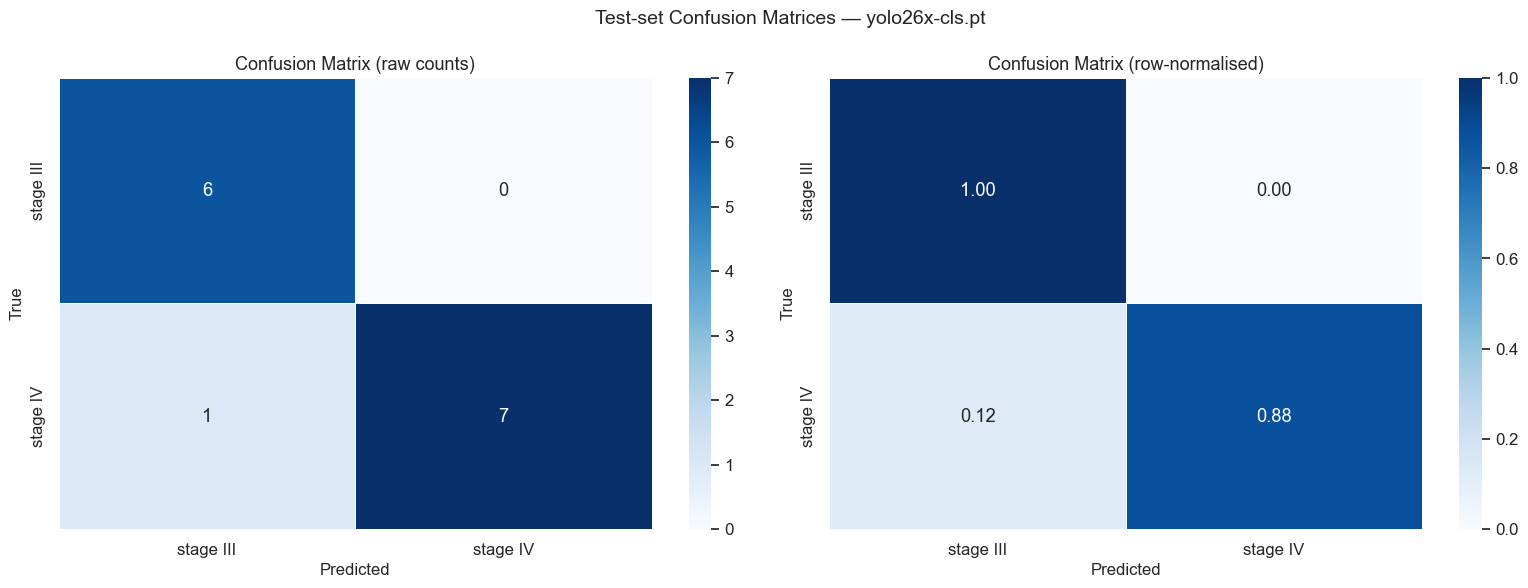

Raw confusion matrix:
           stage III  stage IV
stage III          6         0
stage IV           1         7


In [7]:
model = YOLO(BEST_WEIGHTS)

# Run validation on the TEST split (not val — that was used for early stopping)
test_dir = os.path.join(DEST_DIR, "test")
metrics = model.val(data=test_dir, split="test")

# YOLO appends a background class -> matrix is (n_classes+1) * (n_classes+1) * (n_classes+1) slice to keep only the real classes
n_real = len(model.names)
cm_full = metrics.confusion_matrix.matrix.astype(int)
cm_raw = cm_full[:n_real, :n_real] 
class_names = [model.names[i] for i in range(len(model.names))]

print(f"Full YOLO matrix shape : {cm_full.shape}")
print(f"Trimmed matrix shape : {cm_raw.shape}")
print(f"Classes : {class_names}")

# Normalised (by true class — recall view)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cm, title, fmt in zip(
    axes,
    [cm_raw, cm_norm],
    ["Confusion Matrix (raw counts)", "Confusion Matrix (row-normalised)"],
    ["d", ".2f"],
):
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap="Blues", xticklabels=class_names, 
        yticklabels=class_names, linewidths=0.5, ax=ax,
    )
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(title, fontsize=13)

plt.suptitle(f"Test-set Confusion Matrices — {YOLO_BACKBONE}", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print("Raw confusion matrix:")
print(pd.DataFrame(cm_raw, index=class_names, columns=class_names))


## 7. Evaluation - Full Classification Report

Per-class precision, recall, F1, and support. Both macro and weighted averages shown.

In [8]:
# Reconstruct y_true / y_pred from the confusion matrix
y_true, y_pred = [], []
for true_idx in range(cm_raw.shape[0]):
    for pred_idx in range(cm_raw.shape[1]):
        count = int(cm_raw[true_idx, pred_idx])
        y_true.extend([true_idx] * count)
        y_pred.extend([pred_idx] * count)

print("=" * 55)
print("CLASSIFICATION REPORT — TEST SET")
print("=" * 55)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Summary table
summary = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Macro Precision": precision_score(y_true, y_pred, average="macro"),
    "Macro Recall": recall_score(y_true, y_pred, average="macro"),
    "Macro F1": f1_score(y_true, y_pred, average="macro"),
    "Weighted Precision": precision_score(y_true, y_pred, average="weighted"),
    "Weighted Recall": recall_score(y_true, y_pred, average="weighted"),
    "Weighted F1": f1_score(y_true, y_pred, average="weighted"),
}

df_summary = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
df_summary["Value"] = df_summary["Value"].map("{:.4f}".format)
print()
display(df_summary.set_index("Metric"))

# Save for README
df_summary.to_csv("/kaggle/working/metrics_summary.csv", index=False)
print("\nMetrics saved to metrics_summary.csv")

CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

   stage III     0.8571    1.0000    0.9231         6
    stage IV     1.0000    0.8750    0.9333         8

    accuracy                         0.9286        14
   macro avg     0.9286    0.9375    0.9282        14
weighted avg     0.9388    0.9286    0.9289        14




,Value
Metric,
Accuracy,0.9286
Macro Precision,0.9286
Macro Recall,0.9375
Macro F1,0.9282
Weighted Precision,0.9388
Weighted Recall,0.9286
Weighted F1,0.9289



Metrics saved to metrics_summary.csv


## 8. Evaluation — ROC Curve & AUC

Positive class is `stage IV` - the most severe wound category. A missed Stage IV being called Stage III is the critical error direction: it could mean exposed bone or tendon goes unrecognised and untreated. 

Positive class: 'stage IV' (index 1)

Collected probabilities for 62 test images.
  Stage IV (positive) : 31
  Stage III (negative): 31

AUC-ROC : 0.8366
Youden threshold: 0.707244 (TPR=0.839, FPR=0.194)


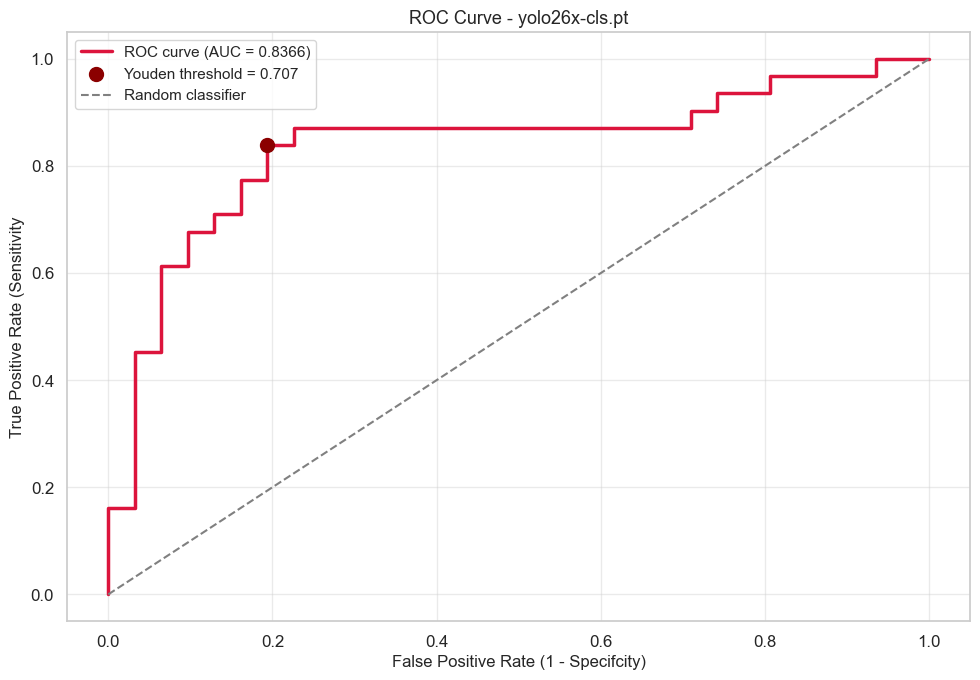

In [9]:
# Collect per-image probabilities from the test set
test_images, gt_labels, pos_probs = [], [], []

# Determine which index is the positive class 
pos_class_name = "stage IV"    # the class treated as "positive" for ROC/AUC
pos_class_idx = next((i for i, name in model.names.items() if pos_class_name in name.lower()), 1) # fallback to index 1
print(f"Positive class: '{model.names[pos_class_idx]}' (index {pos_class_idx})")

for class_idx, class_name in model.names.items():
    class_dir = Path(test_dir) / class_name
    if not class_dir.exists():
        continue
    for img_path in class_dir.glob("*"):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".webp"}:
            continue
        result = model(str(img_path), verbose=False)[0]
        probs = result.probs.data.cpu().numpy()
        pos_probs.append(float(probs[pos_class_idx]))
        gt_labels.append(int(class_idx == pos_class_idx))
        test_images.append(str(img_path))

print(f"\nCollected probabilities for {len(gt_labels)} test images.")
print(f"  Stage IV (positive) : {sum(gt_labels)}")
print(f"  Stage III (negative): {len(gt_labels) - sum(gt_labels)}")


# ROC 
fpr, tpr, thresholds = roc_curve(gt_labels, pos_probs)
auc_score = roc_auc_score(gt_labels, pos_probs)
# Youden's J — optimal threshold (maximises sensitivity + specificity)
j_scores = tpr - fpr
best_thresh_idx = np.argmax(j_scores)
best_threshold = thresholds[best_thresh_idx]

print(f"\nAUC-ROC : {auc_score:.4f}")
print(f"Youden threshold: {best_threshold:4f} (TPR={tpr[best_thresh_idx]:.3f}, FPR={fpr[best_thresh_idx]:.3f})")

# Plot
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(fpr, tpr, color="crimson", lw=2.5, label=f"ROC curve (AUC = {auc_score:.4f})")
ax.scatter(fpr[best_thresh_idx], tpr[best_thresh_idx], color="darkred",
          zorder=5, s=100, label=f"Youden threshold = {best_threshold:.3f}")
ax.plot([0,1], [0,1], linestyle="--", color="grey", lw=1.5, label="Random classifier")
ax.set_xlabel("False Positive Rate (1 - Specifcity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity", fontsize=12)
ax.set_title(f"ROC Curve - {YOLO_BACKBONE}", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Threshold Sensitivity Analysis

Stage III/IV is the most clinically consequential pair -  a Stage IV wound with exposed bone needs immediate surgical consultation. If the Youden threshold gives acceptable Stage IV recall, prefer it over the default 0.5. 

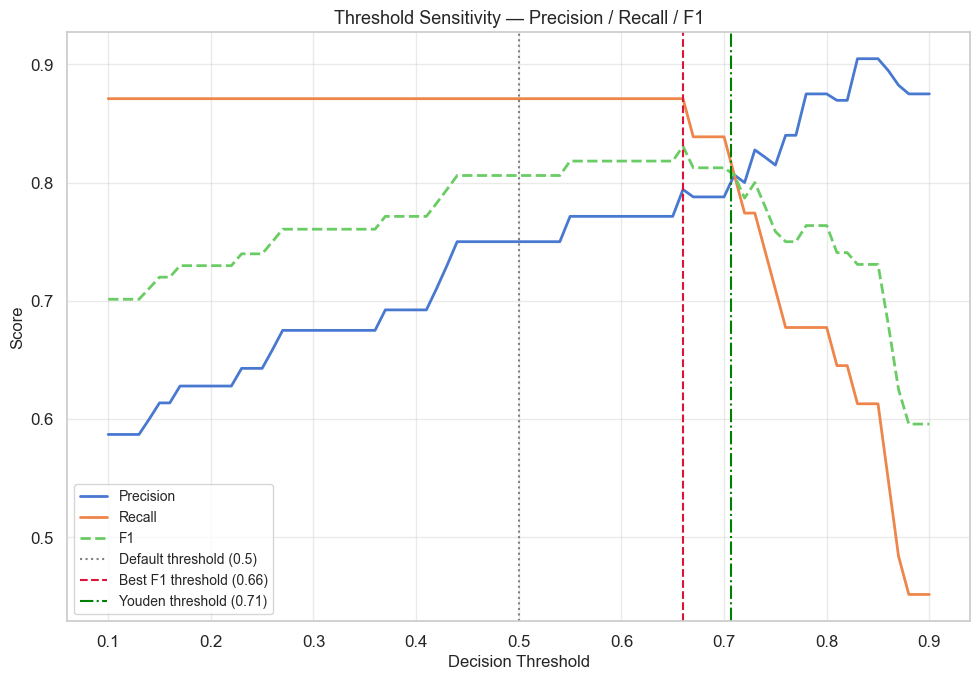

Default threshold (0.5) F1 : 0.8060
Best F1 threshold : 0.66 (F1 = 0.8308)
Youden threshold : 0.71 (F1 = 0.8065)


In [10]:
thresh_range = np.linspace(0.1, 0.9, 81)
precisions, recalls, f1s = [], [], []

for t in thresh_range:
    preds_t = [1 if p >= t else 0 for p in pos_probs]
    precisions.append(precision_score(gt_labels, preds_t, zero_division=0))
    recalls.append(recall_score(gt_labels, preds_t, zero_division=0))
    f1s.append(f1_score(gt_labels, preds_t, zero_division=0))

best_f1_thresh = thresh_range[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(thresh_range, precisions, label="Precision", lw=2)
ax.plot(thresh_range, recalls, label="Recall", lw=2)
ax.plot(thresh_range, f1s, label="F1", lw=2, linestyle="--")
ax.axvline(0.5, color="grey", linestyle=":", lw=1.5, label="Default threshold (0.5)")
ax.axvline(best_f1_thresh, color="crimson", linestyle="--", lw=1.5,
           label=f"Best F1 threshold ({best_f1_thresh:.2f})")
ax.axvline(best_threshold, color="green",  linestyle="-.", lw=1.5,
           label=f"Youden threshold ({best_threshold:.2f})")
ax.set_xlabel("Decision Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Threshold Sensitivity — Precision / Recall / F1", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("/kaggle/working/threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Default threshold (0.5) F1 : {f1s[list(thresh_range).index(min(thresh_range, key=lambda x: abs(x-0.5)))]:.4f}")
print(f"Best F1 threshold : {best_f1_thresh:.2f} (F1 = {max(f1s):.4f})")
print(f"Youden threshold : {best_threshold:.2f} (F1 = {f1s[np.argmin(np.abs(thresh_range - best_threshold))]:.4f})")

## 10. Model Export & Run Summary

In [12]:
print("=" * 55)
print("TRAINING & EVALUATION SUMMARY")
print("=" * 55)
print(f"Backbone : {YOLO_BACKBONE}")
print(f"Best weights : {BEST_WEIGHTS}")
print(f"Test images : {len(gt_labels)}")
print()
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1 : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Weighted F1 : {f1_score(y_true, y_pred, average='weighted'):.4f}")
print(f"AUC-ROC : {auc_score:.4f}")
print()
print(f"Default thresh (0.5)  F1 : {f1s[np.argmin(np.abs(thresh_range - 0.5))]:.4f}")
print(f"Best F1 threshold : {best_f1_thresh:.2f} → F1 = {max(f1s):.4f}")
print(f"Youden threshold : {best_threshold:.2f}")
print()
print("Saved artefacts:")
for fname in [
    "class_distribution.png",
    "training_curves.png",
    "confusion_matrices.png",
    "roc_curve.png",
    "threshold_sensitivity.png",
    "sample_predictions.png",
    "metrics_summary.csv",
]:
    path = Path("/kaggle/working") / fname
    status = "✅" if path.exists() else "❌ missing"
    print(f"  {status}  {fname}")

TRAINING & EVALUATION SUMMARY
Backbone : yolo26x-cls.pt
Best weights : /kaggle/working/runs/cascade_l3_advanced/weights/best.pt
Test images : 62

Accuracy : 0.9286
Macro F1 : 0.9282
Weighted F1 : 0.9289
AUC-ROC : 0.8366

Default thresh (0.5)  F1 : 0.8060
Best F1 threshold : 0.66 → F1 = 0.8308
Youden threshold : 0.71

Saved artefacts:
  ✅  class_distribution.png
  ✅  training_curves.png
  ✅  confusion_matrices.png
  ✅  roc_curve.png
  ✅  threshold_sensitivity.png
  ✅  sample_predictions.png
  ✅  metrics_summary.csv
